<a href="https://colab.research.google.com/github/SunkeSruthi603/Arudino_bot/blob/main/Brain_Tumor_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install scikit-learn
!pip install split-folders
!pip install tensorflow
!pip install opencv-python
!pip install imutils
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, shutil
import cv2
import time
import zipfile
import tensorflow as tf
import imutils
import splitfolders
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras import Sequential
import matplotlib.image as mpimg
import seaborn as sns
%matplotlib inline
plt.style.use("ggplot")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 108.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 112.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25835 sha256=a83eb4bb6e00f2d5a3f286a74758abba22888a6ae3f6f41290607e0ad756df64
  Stored in directory: /root/.cache/pip/wheels/31/d0/2c/87ce38f6052879e5b7b18f0f8b4a10ad2a9d210e908d449f16
Successfully built imutils


In [5]:
#2.Extracting the Data
zip_file = "/content/archive.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("Brain Tumor Dataset")

In [6]:
#3.EDA
base_path = "/content/Brain Tumor Dataset/Training"
tumor_types = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]

def count_files(base_path):
  for tumor_type in tumor_types:
    folder_path = os.path.join(base_path, tumor_type)
    if os.path.exists(folder_path):
      file_list = os.listdir(folder_path)
      print(f"Number of files in {tumor_type}: {len(file_list)}")
    else:
      print(f"Folder not found: {folder_path}")

print ("Brain Tumor MRI Dataset EDA")
count_files(base_path)

Brain Tumor MRI Dataset EDA
Number of files in glioma_tumor: 826
Number of files in meningioma_tumor: 822
Number of files in no_tumor: 395
Number of files in pituitary_tumor: 827


In [13]:

#4.Data Augmentation
def timing(sec_elapsed):
  h = int(sec_elapsed / (60 * 60))
  m = int((sec_elapsed % (60 * 60)) / 60)
  s = sec_elapsed % 60
  return f"{h}:{m}:{s}"


def augmented_data(base_dir, n_generated_samples, save_base_dir):
  data_gen = ImageDataGenerator(
      rotation_range=10,
      width_shift_range=0.1,
      height_shift_range=0.1,
      shear_range=0.1,
      brightness_range=(0.3,0.1),
      horizontal_flip=True,
      vertical_flip=True,
      fill_mode='nearest'
  )

  start_time = time.time()

  for tumor_type in tumor_types:
      source_dir = os.path.join(base_dir, tumor_type)
      save_dir = os.path.join(save_base_dir, tumor_type)
      os.makedirs(save_dir, exist_ok=True)

      for filename in os.listdir(source_dir):
        image = cv2.imread(os.path.join(source_dir, filename))
        image = image.reshape((1,) + image.shape)
        save_prefix = 'aug_' + filename[:-4]
        i =0

        for batch in data_gen.flow(x=image, batch_size=1, save_to_dir=save_dir, save_prefix=save_prefix, save_format="jpg"):
          i+=1
          if(i>= n_generated_samples):
            break

  end_time = time.time()
  print(f"Data augmentation completed in: {timing(end_time-start_time)}")

base_dir = '/content/Brain Tumor Dataset/Training'
n_generated_samples = 5
save_base_dir = '/content/Augmented Data'
augmented_data(base_dir, n_generated_samples, save_base_dir)

Data augmentation completed in: 0:12:27.570469856262207


In [14]:
#5.Renaming files
def rename_files(folder, tumor_name):
  count = 1
  for filename in os.listdir(folder):
    source = os.path.join(folder, filename)
    destination = os.path.join(folder, f"{tumor_name}_{count}.jpg")
    os.rename(source, destination)
    count += 1
  print(f"{tumor_name} Tumor Images Renamed Successfully")

for tumor in tumor_types:
  folder = f'/content/Augmented Data/{tumor}'
  rename_files(folder, tumor)

glioma_tumor Tumor Images Renamed Successfully
meningioma_tumor Tumor Images Renamed Successfully
no_tumor Tumor Images Renamed Successfully
pituitary_tumor Tumor Images Renamed Successfully


Tumor type counts (Augmented Date): [4129, 4110, 1975, 4133]


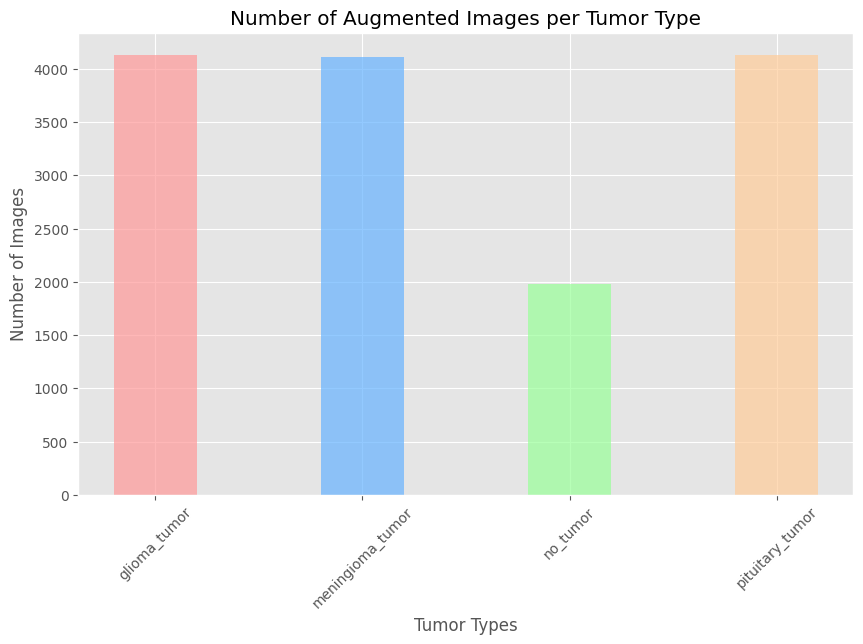

In [16]:
#6.Visualize Dataset
tumor_counts = [len(os.listdir(os.path.join(save_base_dir, tumor))) for tumor in tumor_types]
print("Tumor type counts (Augmented Date):", tumor_counts)

colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
x = np.arange(len(tumor_types))
width = 0.4

plt.figure(figsize=(10, 6))
plt.bar(x, tumor_counts, width=width, align='center' , alpha=0.7, color=colors)
plt.xlabel('Tumor Types')
plt.ylabel('Number of Images')
plt.title('Number of Augmented Images per Tumor Type')
plt.xticks(x, tumor_types , rotation=45)
plt.show()

In [17]:
#7.Croping Brain Tumors by removing the black parts
def crop_brain_tumor(image):
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  gray = cv2.GaussianBlur(gray, (5,5), 0)
  thres = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
  thres = cv2.erode(thres, None, iterations=2)
  thres = cv2.dilate(thres, None, iterations=2)
  cnts = cv2.findContours(thres.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  cnts = imutils.grab_contours(cnts)

  if len(cnts) == 0:
    return image
  c = max(cnts, key=cv2.contourArea)
  extLeft = tuple(c[c[:, :, 0].argmin()][0])
  extRight = tuple(c[c[:, :, 0].argmax()][0])
  extTop = tuple(c[c[:, :, 1].argmin()][0])
  extBot = tuple(c[c[:, :, 1].argmax()][0])

  cropped_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]
  return cropped_image

def crop_and_save_images(folder_path):
  for filename in os.listdir(folder_path):
    image_path = os.path.join(folder_path, filename)
    image = cv2.imread(image_path)

    if image is not None:
      cropped_image = crop_brain_tumor(image)
      cv2.imwrite(image_path, cropped_image)
      print(f"Processed: {filename}")
    else:
      print(f"Failed to read: {filename}")
for tumor in tumor_types:
  folder_path = os.path.join(save_base_dir, tumor)
  print(f"Processing folder: {folder_path}")
  crop_and_save_images(folder_path)

Streaming output truncated to the last 5000 lines.
Processed: no_tumor_919.jpg
Processed: no_tumor_1691.jpg
Processed: no_tumor_1967.jpg
Processed: no_tumor_580.jpg
Processed: no_tumor_1091.jpg
Processed: no_tumor_1777.jpg
Processed: no_tumor_1602.jpg
Processed: no_tumor_790.jpg
Processed: no_tumor_1699.jpg
Processed: no_tumor_1604.jpg
Processed: no_tumor_800.jpg
Processed: no_tumor_1078.jpg
Processed: no_tumor_1011.jpg
Processed: no_tumor_256.jpg
Processed: no_tumor_1369.jpg
Processed: no_tumor_1337.jpg
Processed: no_tumor_823.jpg
Processed: no_tumor_806.jpg
Processed: no_tumor_1154.jpg
Processed: no_tumor_1310.jpg
Processed: no_tumor_618.jpg
Processed: no_tumor_1506.jpg
Processed: no_tumor_1836.jpg
Processed: no_tumor_1045.jpg
Processed: no_tumor_1790.jpg
Processed: no_tumor_493.jpg
Processed: no_tumor_542.jpg
Processed: no_tumor_921.jpg
Processed: no_tumor_1476.jpg
Processed: no_tumor_957.jpg
Processed: no_tumor_1336.jpg
Processed: no_tumor_735.jpg
Processed: no_tumor_158.jpg
Proces

In [18]:
#8.split Data

input_folder = '/content/Augmented Data'
output_folder = '/content/Split Data'

splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(0.8, 0.1, 0.1))
print("Dataset successfully split into trainingg , validation and test sets")

Copying files: 14347 files [00:01, 7269.16 files/s]

Dataset successfully split into trainingg , validation and test sets


In [19]:
import shutil
from google.colab import files

shutil.make_archive('Split_Data', 'zip', '/content/Split Data')

files.download('Split_Data.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
#9.CNN model

def build_cnn_model():
  model = Sequential([
      layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
      layers.MaxPooling2D((2,2)),
      layers.Conv2D(64, (3,3), activation='relu'),
      layers.MaxPooling2D((2,2)),
      layers.Conv2D(128, (3,3), activation='relu'),
      layers.MaxPooling2D((2,2)),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dropout(0.5),
      layers.Dense(4, activation='softmax') # 4 classes
  ])

  model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])
  return model

model = build_cnn_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#10.Prepare Data Generators

train_dir = '/content/Split Data/train'
val_dir = '/content/Split Data/val'
test_dir = '/content/Split Data/test'

train_datagen = ImageDataGenerator(
    rescale=1./225,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./225)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

Found 11477 images belonging to 4 classes.
Found 1433 images belonging to 4 classes.
Found 1437 images belonging to 4 classes.


In [26]:
#Training the model

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
checkpoint = tf.keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only=True)

history = model.fit(
    train_generator,
    epochs = 20,
    validation_data = val_generator,
    callbacks =[early_stop, checkpoint]
)

Epoch 1/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.5084 - loss: 1.0745

359/359 ━━━━━━━━━━━━━━━━━━━━ 293s 816ms/step - accuracy: 0.5086 - loss: 1.0742 - val_accuracy: 0.6329 - val_loss: 0.8223
Epoch 2/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 789ms/step - accuracy: 0.6246 - loss: 0.8739

359/359 ━━━━━━━━━━━━━━━━━━━━ 292s 813ms/step - accuracy: 0.6247 - loss: 0.8738 - val_accuracy: 0.6671 - val_loss: 0.7175
Epoch 3/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.6937 - loss: 0.7363

359/359 ━━━━━━━━━━━━━━━━━━━━ 290s 807ms/step - accuracy: 0.6937 - loss: 0.7362 - val_accuracy: 0.7237 - val_loss: 0.6279
Epoch 4/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 290s 808ms/step - accuracy: 0.7408 - loss: 0.6301 - val_accuracy: 0.7160 - val_loss: 0.7150
Epoch 5/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.7619 - loss: 0.5581

359/359 ━━━━━━━━━━━━━━━━━━━━ 291s 811ms/step - accuracy: 0.7619 - loss: 0.5581 - val_accuracy: 0.7753 - val_loss: 0.5919
Epoch 6/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.7898 - loss: 0.5246

...

359/359 ━━━━━━━━━━━━━━━━━━━━ 290s 808ms/step - accuracy: 0.8465 - loss: 0.3954 - val_accuracy: 0.8639 - val_loss: 0.3475
Epoch 11/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 287s 799ms/step - accuracy: 0.8573 - loss: 0.3656 - val_accuracy: 0.8569 - val_loss: 0.3694
Epoch 12/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 286s 796ms/step - accuracy: 0.8600 - loss: 0.3718 - val_accuracy: 0.8521 - val_loss: 0.3723
Epoch 13/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.8650 - loss: 0.3557

359/359 ━━━━━━━━━━━━━━━━━━━━ 287s 799ms/step - accuracy: 0.8650 - loss: 0.3557 - val_accuracy: 0.8758 - val_loss: 0.3237
Epoch 14/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.8825 - loss: 0.3101

359/359 ━━━━━━━━━━━━━━━━━━━━ 292s 814ms/step - accuracy: 0.8825 - loss: 0.3101 - val_accuracy: 0.8911 - val_loss: 0.2860
Epoch 15/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.8786 - loss: 0.3118

359/359 ━━━━━━━━━━━━━━━━━━━━ 291s 810ms/step - accuracy: 0.8786 - loss: 0.3118 - val_accuracy: 0.9093 - val_loss: 0.2401
Epoch 16/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 292s 812ms/step - accuracy: 0.8903 - loss: 0.2865 - val_accuracy: 0.9030 - val_loss: 0.2470
Epoch 17/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.8838 - loss: 0.3014

359/359 ━━━━━━━━━━━━━━━━━━━━ 290s 808ms/step - accuracy: 0.8838 - loss: 0.3014 - val_accuracy: 0.9100 - val_loss: 0.2255
Epoch 18/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 291s 809ms/step - accuracy: 0.8942 - loss: 0.2724 - val_accuracy: 0.8765 - val_loss: 0.3238
Epoch 19/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 289s 805ms/step - accuracy: 0.9035 - loss: 0.2590 - val_accuracy: 0.9072 - val_loss: 0.2526
Epoch 20/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 290s 808ms/step - accuracy: 0.9076 - loss: 0.2376 - val_accuracy: 0.8925 - val_loss: 0.2901


In [1]:
#Evaluate
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

NameError: name 'model' is not defined

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load the trained model
model = tf.keras.models.load_model('/content/best_model.h5')
class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

def load_and_preprocess_image(image_path):
    img = image.load_img(image_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array/ 255.0
    return img, img_array

def predict_image(image_path):
    img, img_array = load_and_preprocess_image(image_path)
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Predicted Class: {class_names[predicted_class[0]]}')
    plt.show()
    # plt.title(f'Predicted Class: {class_names[predicted_class[0]]}')

img_path = '/content/Split Data/test/glioma_tumor/glioma_tumor_101.jpg'
predict_image(img_path)